In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_age_manual_bins.csv')
significant_birth_year_coef_df = coef_df[(coef_df['variable'] == 'birth_year') & (coef_df['fdr_p'] < 0.05)]
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")


In [3]:
print(f"Columns in significant_birth_year_coef_df: {significant_birth_year_coef_df.columns.tolist()}")
print(f"Columns in atlas_csv: {atlas_csv.columns.tolist()}")

Columns in significant_birth_year_coef_df: ['age_bin', 'region_label', 'variable', 'coef', 't', 'p', 'fdr_p', 'region_name']
Columns in atlas_csv: ['Unnamed: 0', 'index', 'name', 'base_name', 'Label Name', 'network', 'component', 'hemisphere']


In [4]:
# merge atlas to significant_birth_year_coef_df

# reanme atlas_csv['index']
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})
sig_coef_df = significant_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')
sig_coef_df['network_component'] = sig_coef_df['network'] + '_' + sig_coef_df['component']


In [16]:
# add a manual functional aggregation 

manual_func_agg = {
    'anxiety / negative affect / emotional salience': [
        'subcortex_Amygdala',
        'salience / ventral attention_frontal operculum insula',
        'salience / ventral attention_medial',
        'salience / ventral attention_temporal occipital parietal',
        'salience / ventral attention_temporal occipital',
        'salience / ventral attention_parietal operculum',
        'limbic_orbital frontal cortex',
        'limbic_temporal pole'
    ],

    'attention (dorsal & ventral) / orienting / vigilance': [
        'dorsal attention_posterior',
        'dorsal attention_frontal eye fields',
        'dorsal attention_precentral ventral',
        'salience / ventral attention_lateral prefrontal cortex',
        'salience / ventral attention_temporal occipital parietal',
        'salience / ventral attention_temporal occipital',
        'salience / ventral attention_parietal operculum',
        'subcortex_Thalamus'
    ],

    'executive functions / cognitive control': [
        'control_lateral prefrontal cortex',
        'control_parietal',
        'control_parietal ',
        'control_ventral prefrontal cortex',
        'control_medial posterior prefrontal cortex',
        'control_cingulate',
        'control_orbital frontal cortex',
        'control_precuneus',
        'control_temporal'
    ],

    'default mode / self-referential / internal mentation': [
        'default_precuneus posterior cingulate cortex',
        'default_prefrontal cortex',
        'default_dorsal prefrontal cortex medial prefrontal cortex',
        'default_parietal',
        'default_temporal',
        'default_ventral prefrontal cortex',
        'control_precuneus'
    ],

    'reward / motivation / approach-avoidance': [
        'subcortex_Nucleus Accumbens',
        'subcortex_Putamen',
        'subcortex_Caudate',
        'subcortex_Caudate body',
        'subcortex_Caudate tail',
        'limbic_orbital frontal cortex',
        'limbic_temporal pole'
    ],

    'memory / episodic / contextual': [
        'subcortex_Hippocampus head',
        'subcortex_Hippocampus body',
        'subcortex_Hippocampus tail',
        'default_temporal',
        'default_precuneus posterior cingulate cortex'
    ],

    'communication / social cognition': [
        'limbic_temporal pole',
        'limbic_orbital frontal cortex',
        'default_prefrontal cortex',
        'default_dorsal prefrontal cortex medial prefrontal cortex',
        'default_parietal',
        'control_lateral prefrontal cortex',
        'control_parietal',
        'control_cingulate'
    ],

    'sensorimotor / motor control': [
        'somatomotor_somatomotor',
        'visual_visual',
        'subcortex_Pallidum',
        'subcortex_Putamen',
        'subcortex_Caudate',
        'subcortex_Caudate body',
        'subcortex_Caudate tail',
        'dorsal attention_precentral ventral',
        'dorsal attention_frontal eye fields'
    ],

    'sensory / perceptual': [
        'visual_visual',
        'subcortex_Thalamus',
        'salience / ventral attention_temporal occipital parietal',
        'salience / ventral attention_temporal occipital'
    ]
}


# add manual_functional_aggregation based on 'network_component' and the mapping manual_func_agg
sig_coef_df['manual_functional_aggregation'] = sig_coef_df['network_component'].map(lambda x: next((k for k, v in manual_func_agg.items() if any(region in x for region in v)), 'other'))


In [17]:
print(sig_coef_df.columns.tolist())

['age_bin', 'region_label', 'variable', 'coef', 't', 'p', 'fdr_p', 'region_name', 'network', 'component', 'hemisphere', 'network_component', 'manual_functional_aggregation']


In [18]:
print(sig_coef_df['network_component'].unique())

['subcortex_Pallidum'
 'salience / ventral attention_temporal occipital parietal'
 'limbic_orbital frontal cortex' 'control_lateral prefrontal cortex'
 'dorsal attention_posterior' 'somatomotor_somatomotor'
 'limbic_temporal pole' 'subcortex_Amygdala' 'control_temporal'
 'default_parietal' 'subcortex_Nucleus Accumbens'
 'default_precuneus posterior cingulate cortex' 'control_precuneus'
 'default_temporal' 'visual_visual' 'subcortex_Thalamus'
 'default_prefrontal cortex' 'subcortex_Putamen'
 'salience / ventral attention_frontal operculum insula'
 'salience / ventral attention_medial' 'control_ventral prefrontal cortex'
 'subcortex_Caudate' 'subcortex_Hippocampus head'
 'dorsal attention_frontal eye fields' 'control_parietal'
 'control_cingulate'
 'default_dorsal prefrontal cortex medial prefrontal cortex'
 'salience / ventral attention_temporal occipital'
 'default_ventral prefrontal cortex' 'dorsal attention_precentral ventral'
 'subcortex_Caudate body' 'subcortex_Caudate tail'
 'sali

# plot

In [19]:
# plot for each 

In [20]:
def apply_plot_style(ax, title, xlabel="Age Bin", ylabel="Coefficient"):
    """Centralized function for consistent visual styling."""
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    sns.despine() # Makes the plot cleaner
    plt.tight_layout()

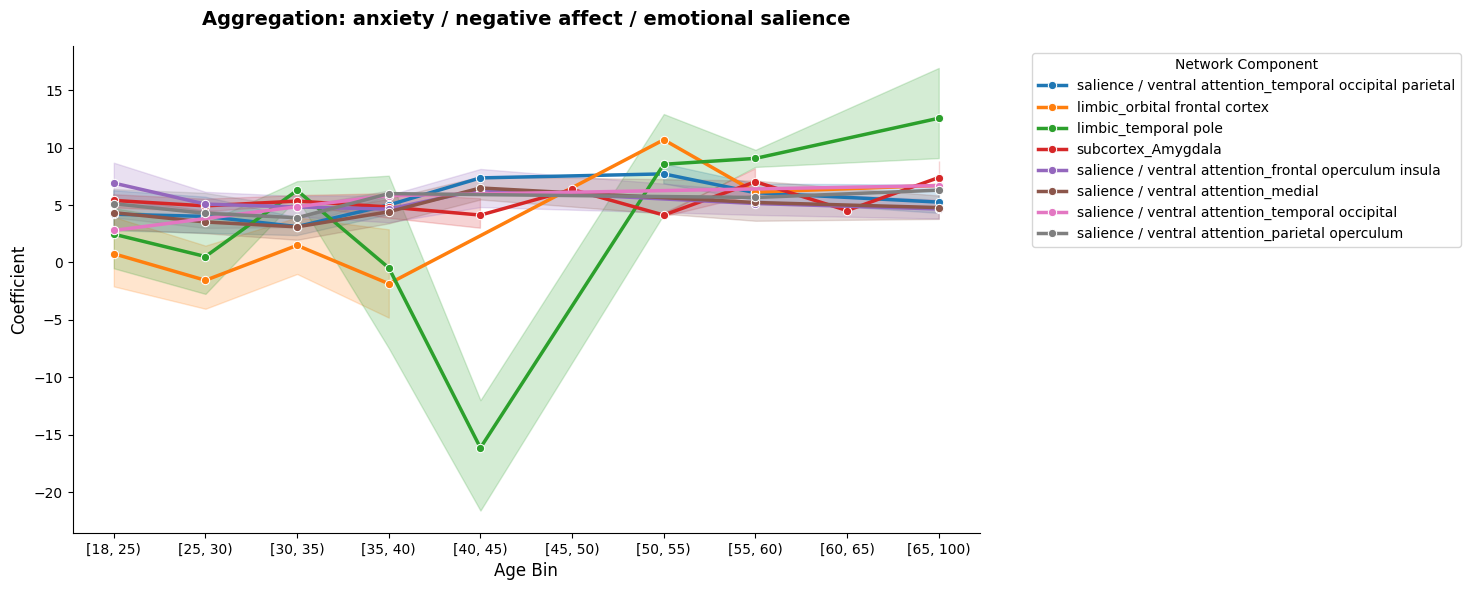

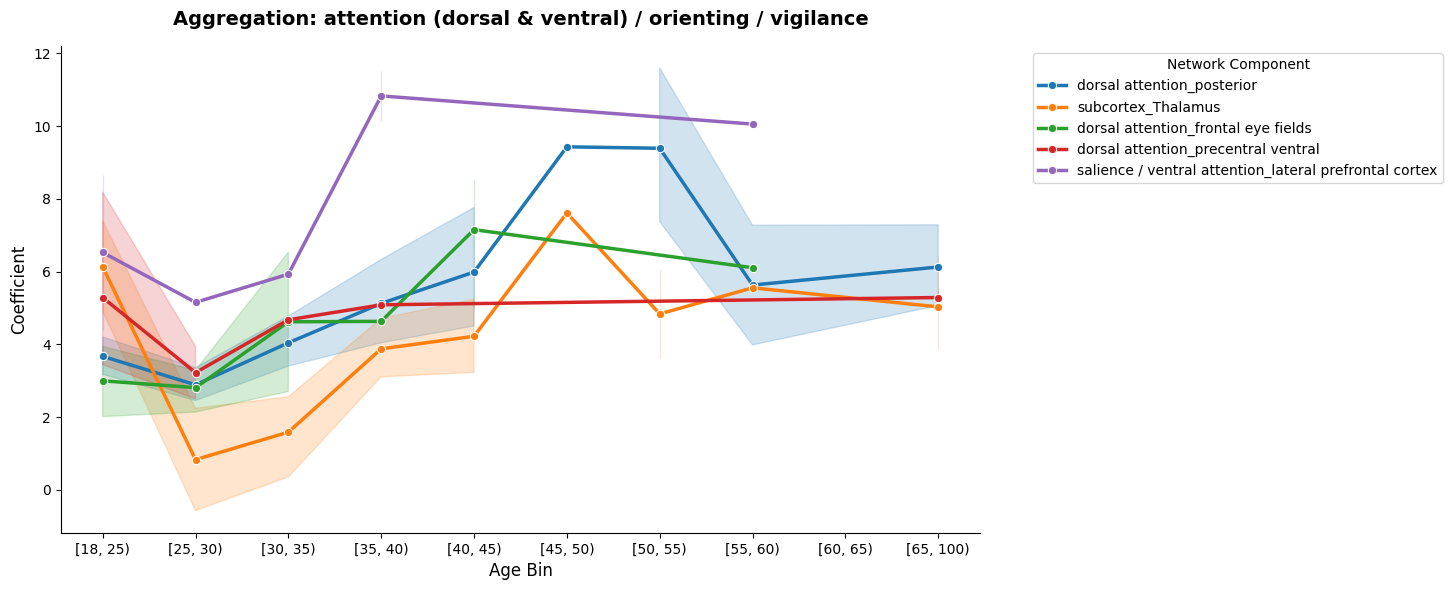

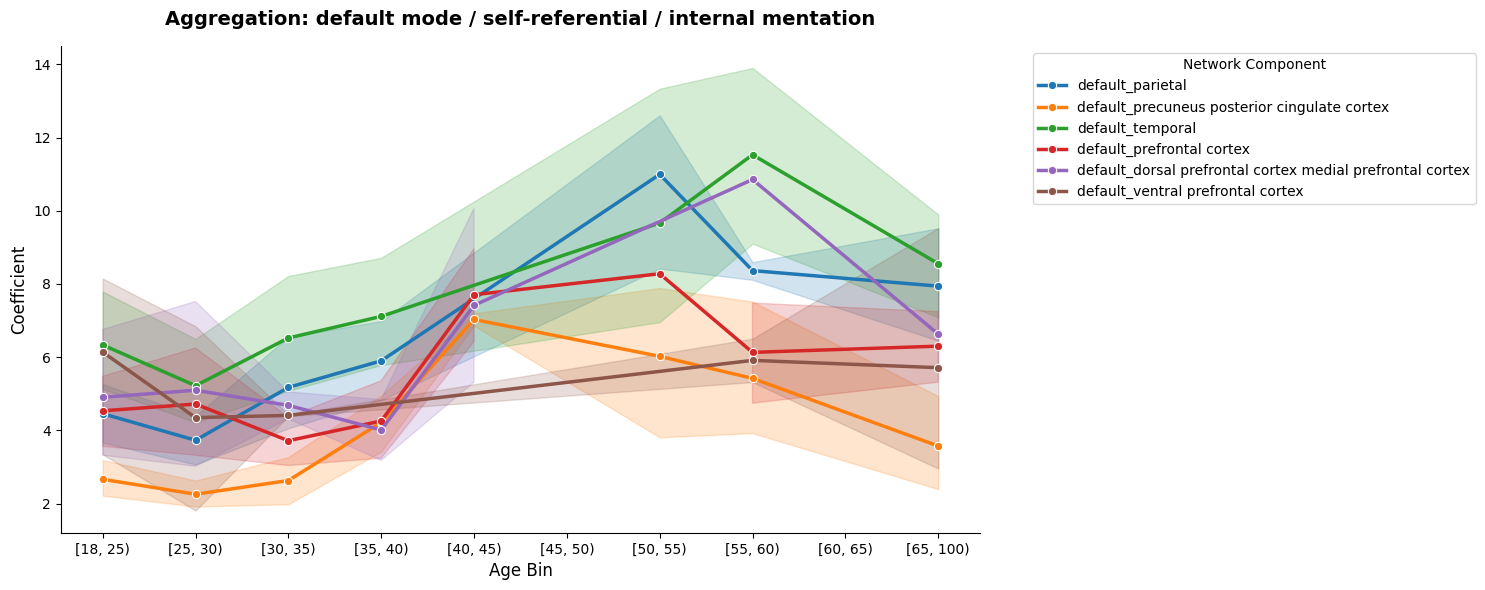

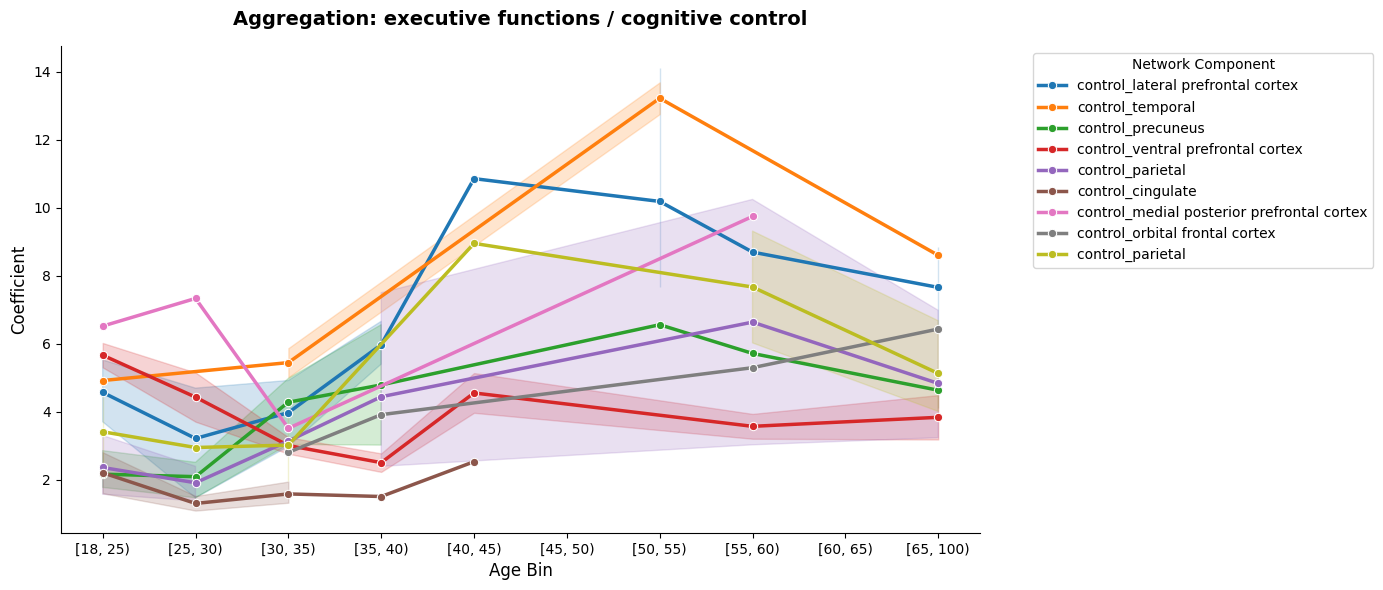

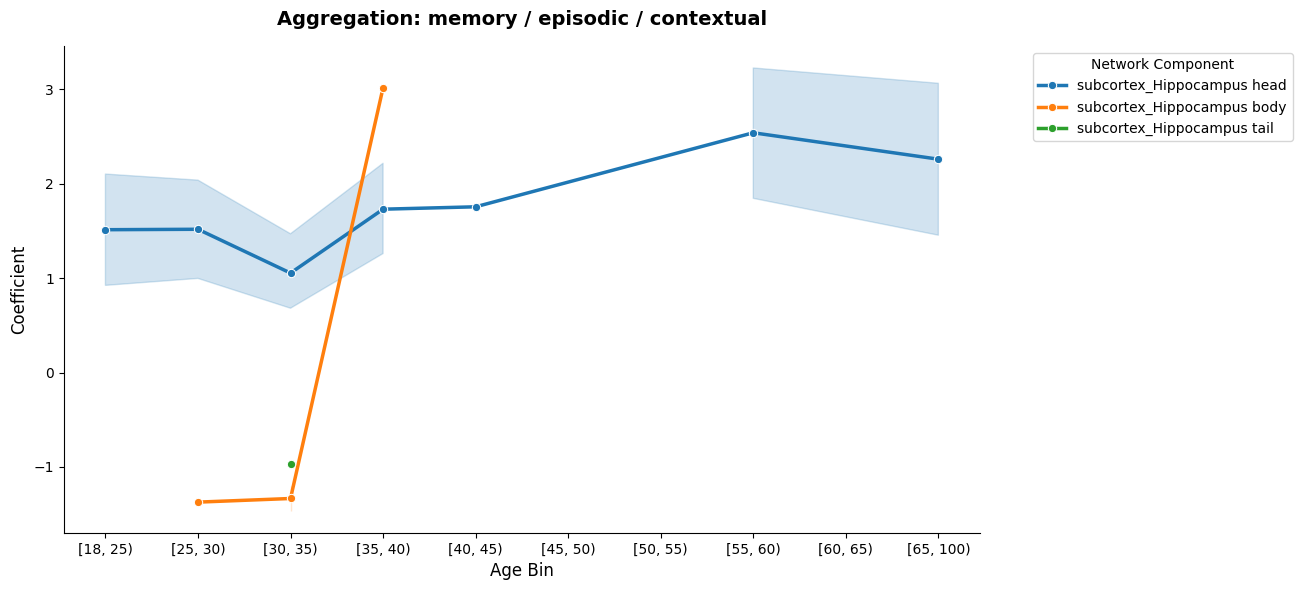

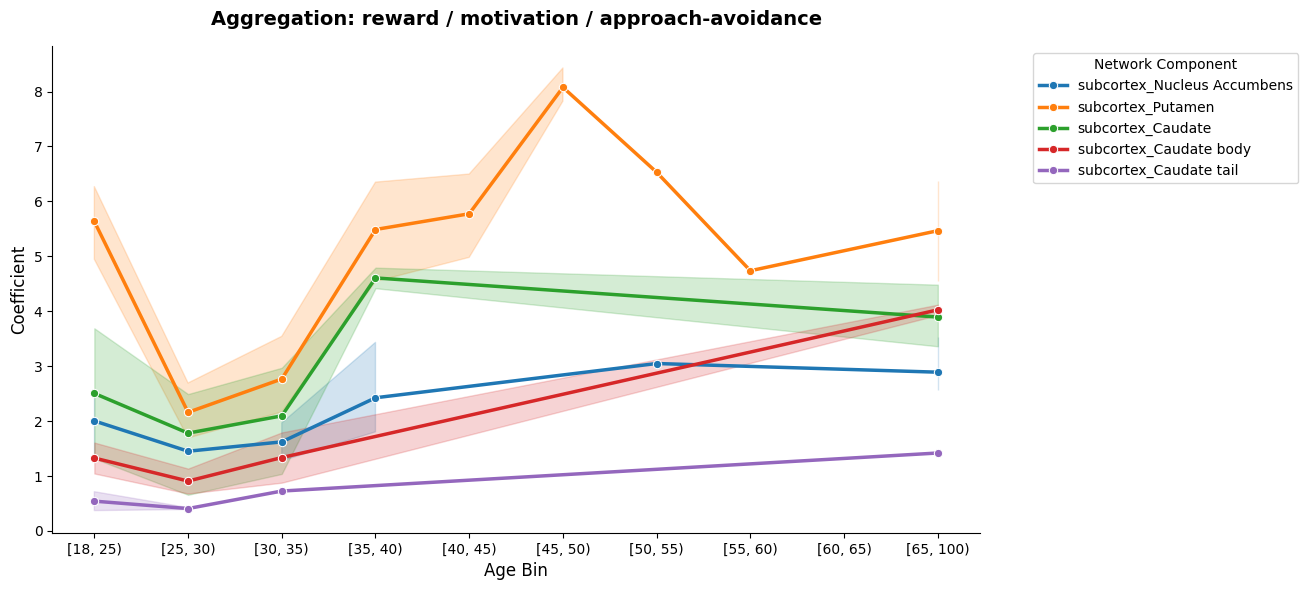

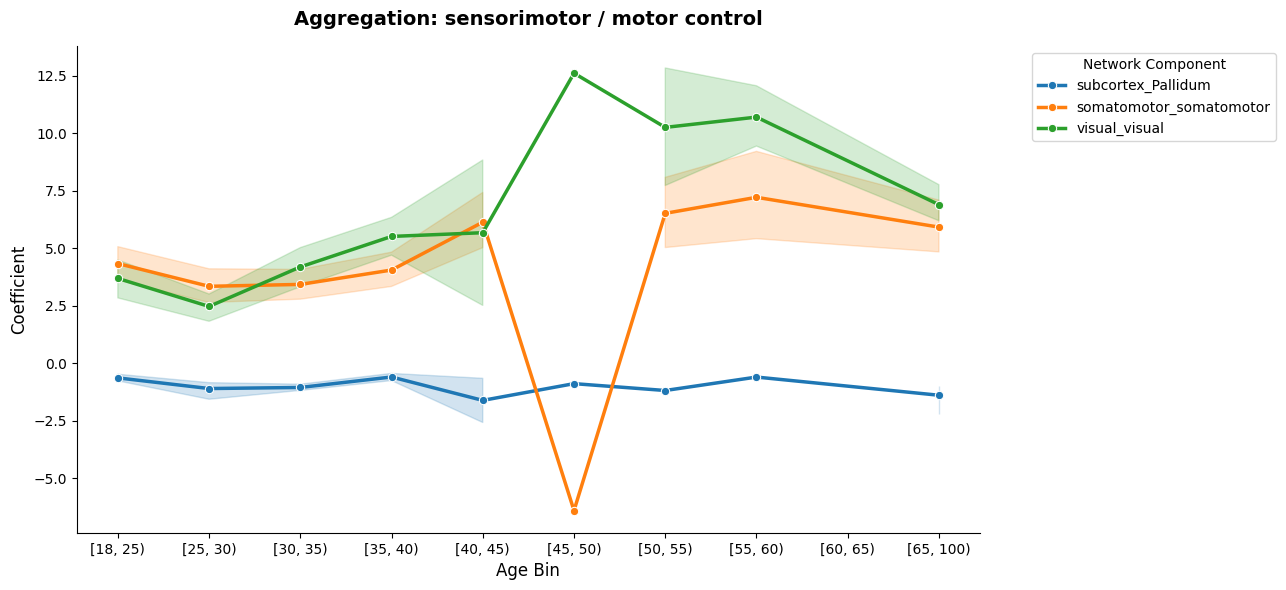

In [22]:
# 1. Ensure age_bin is ordered chronologically
# Replace this list with your actual age bin order
age_order = sorted(sig_coef_df['age_bin'].unique()) 
sig_coef_df['age_bin'] = pd.Categorical(sig_coef_df['age_bin'], categories=age_order, ordered=True)

# 2. Group by the higher-level aggregation
groups = sig_coef_df.groupby('manual_functional_aggregation')

for agg_name, agg_sig_coef_df in groups:
    # Create a new figure for each manual_functional_aggregation
    plt.figure(figsize=(10, 6))
    
    # 3. Plot all network_components within this aggregation
    # 'hue' handles the secondary level plotting automatically
    sns.lineplot(
        data=agg_sig_coef_df,
        x='age_bin',
        y='coef',
        hue='network_component',
        marker='o',
        linewidth=2.5
    )

    # 4. Apply styling
    apply_plot_style(plt.gca(), title=f"Aggregation: {agg_name}")
    
    # Adjust legend to be outside the plot if it gets crowded
    plt.legend(title='Network Component', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.show()

In [ ]:
print(sig_coef_df['network_component'].unique())

['subcortex_Pallidum'
 'salience / ventral attention_temporal occipital parietal'
 'limbic_orbital frontal cortex' 'control_lateral prefrontal cortex'
 'dorsal attention_posterior' 'somatomotor_somatomotor'
 'limbic_temporal pole' 'subcortex_Amygdala' 'control_temporal'
 'default_parietal' 'subcortex_Nucleus Accumbens'
 'default_precuneus posterior cingulate cortex' 'control_precuneus'
 'default_temporal' 'visual_visual' 'subcortex_Thalamus'
 'default_prefrontal cortex' 'subcortex_Putamen'
 'salience / ventral attention_frontal operculum insula'
 'salience / ventral attention_medial' 'control_ventral prefrontal cortex'
 'subcortex_Caudate' 'subcortex_Hippocampus head'
 'dorsal attention_frontal eye fields' 'control_parietal'
 'control_cingulate'
 'default_dorsal prefrontal cortex medial prefrontal cortex'
 'salience / ventral attention_temporal occipital'
 'default_ventral prefrontal cortex' 'dorsal attention_precentral ventral'
 'subcortex_Caudate body' 'subcortex_Caudate tail'
 'sali